In [1]:
from FLUX_custom_pipeline import FluxPipeline
import torch
import torch.nn.functional as F
import torch
from FLUX_custom_transformer import FluxTransformer2DModel
from scipy.stats import spearmanr

In [2]:
# Load your custom transformer
custom_transformer = FluxTransformer2DModel.from_pretrained(
    "black-forest-labs/FLUX.1-dev",
    subfolder="transformer",
    torch_dtype=torch.float16
)

# Load pipeline with custom transformer
pipe = FluxPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-dev",
    transformer=custom_transformer,
    torch_dtype=torch.float16
)
pipe.enable_model_cpu_offload()
pipe.activation_patching = True

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Using Custom Transformer!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Performing standard CFG with scale 3.5.


  0%|          | 0/3 [00:00<?, ?it/s]

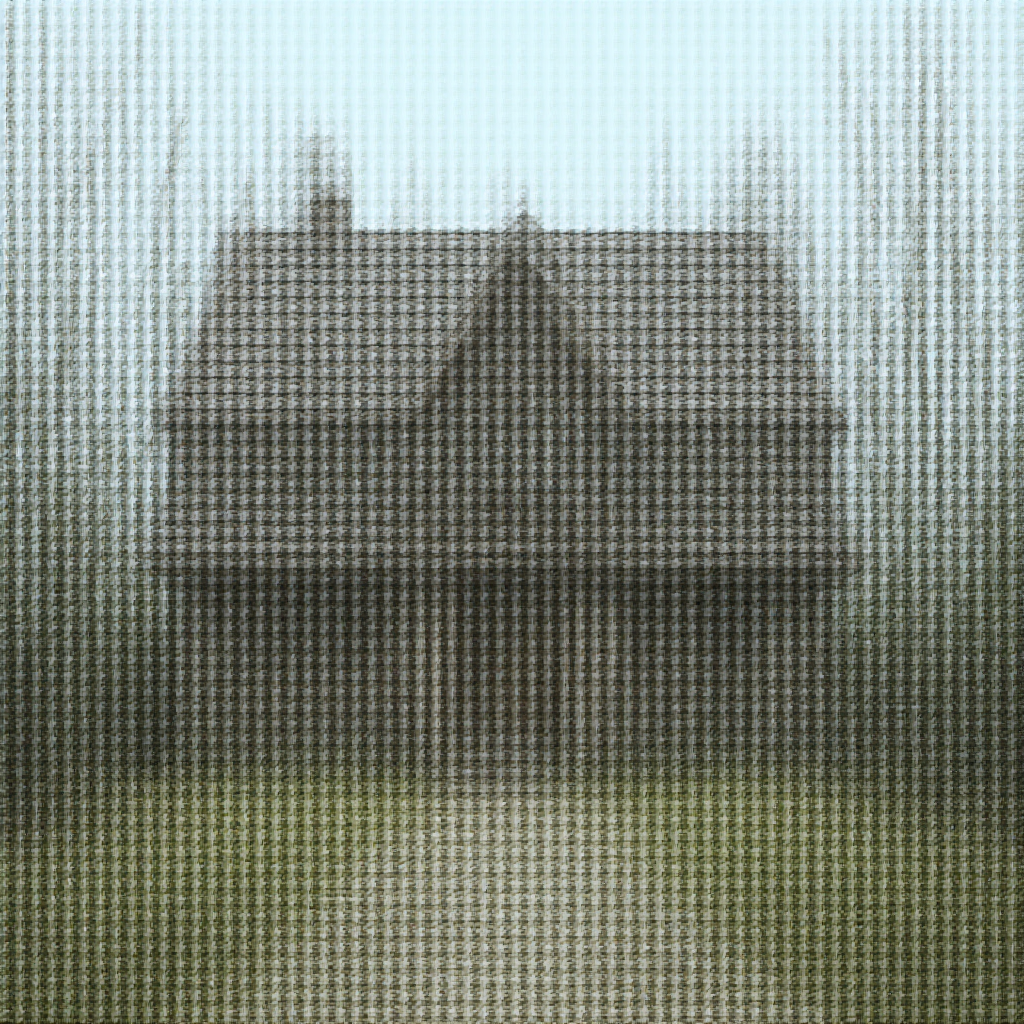

In [3]:
pipe.skipped_latents = []
pipe.unskipped_latents = []
pipe.patch_prompt = "A beautiful, aesthetically pleasing house"
image = pipe(
    "A normal house",
    generator=torch.Generator("cpu").manual_seed(42),
    num_inference_steps=3
).images[0]
image

In [6]:
layer_diffs = []
for timestep in range(10): 
    timestep_prediction = pipe.unskipped_latents[timestep]
    timestep_baseline = pipe.skipped_latents[timestep][19]

    diff_baseline = (timestep_prediction - timestep_baseline)
    squared_norm_baseline = torch.sum(diff_baseline ** 2, dim=[0,1,2])

    layer_diffs_per_timestep = []
    for layer in range(19):
        diff = (timestep_prediction - pipe.skipped_latents[timestep][layer])
        squared_norm = torch.sum(diff ** 2, dim=[0,1,2]) 
        layer_diffs_per_timestep.append(squared_norm) #- squared_norm_baseline
    layer_diffs.append(torch.stack(layer_diffs_per_timestep))
layer_diffs = torch.stack(layer_diffs)

layer_weights = torch.tensor([
    6.182411,  # layer_0
    5.620659,  # layer_1
    5.538202,  # layer_2
    6.934737,  # layer_3
    6.919821,  # layer_4
    6.967773,  # layer_5
    7.036552,  # layer_6
    6.975098,  # layer_7
    7.044626,  # layer_8
    7.078791,  # layer_9
    7.019176,  # layer_10
    6.995934,  # layer_11
    7.118817,  # layer_12
    7.066835,  # layer_13
    7.034940,  # layer_14
    7.136667,  # layer_15
    6.815899,  # layer_16
    6.722664,  # layer_17
    6.960558,  # layer_18
])[:]

layer_weight = torch.tensor([6.414817,
    6.012494,
    5.183740,
    6.884494,
    6.954563,
    6.978050,
    7.020353,
    6.937215,
    7.028258,
    6.980995,
    7.022676,
    7.007033,
    7.024124,
    7.002501,
    7.043288,
    7.050234,
    6.891521,
    6.890457,
    6.825743])

import torch
from scipy.stats import spearmanr

# Example tensors
tensor1 = layer_weights.to('cpu')[3:]
tensor2 = layer_diffs[:].mean(dim=0).to('cpu')[3:]
#tensor2 = cosine_sims.mean(dim=0).to('cpu')[3:]
#tensor2 = cosine_sims[i].to('cpu')[3:]

# Spearman correlation (using scipy)
spearman_corr, p_value = spearmanr(tensor1.numpy(), tensor2.numpy())
print(f"Spearman correlation: {spearman_corr:.6f}")
print(f"Spearman p-value: {p_value:.6f}")

# Alternative: Using torch.corrcoef for Pearson
stacked = torch.stack([tensor1, tensor2])
corr_matrix = torch.corrcoef(stacked)
pearson_corr_alt = corr_matrix[0, 1]
print(f"Pearson correlation (torch.corrcoef): {pearson_corr_alt.item():.6f}")

Spearman correlation: -0.241532
Spearman p-value: 0.367479
Pearson correlation (torch.corrcoef): -0.017052


Performing standard CFG with scale 3.5.


  0%|          | 0/20 [00:00<?, ?it/s]

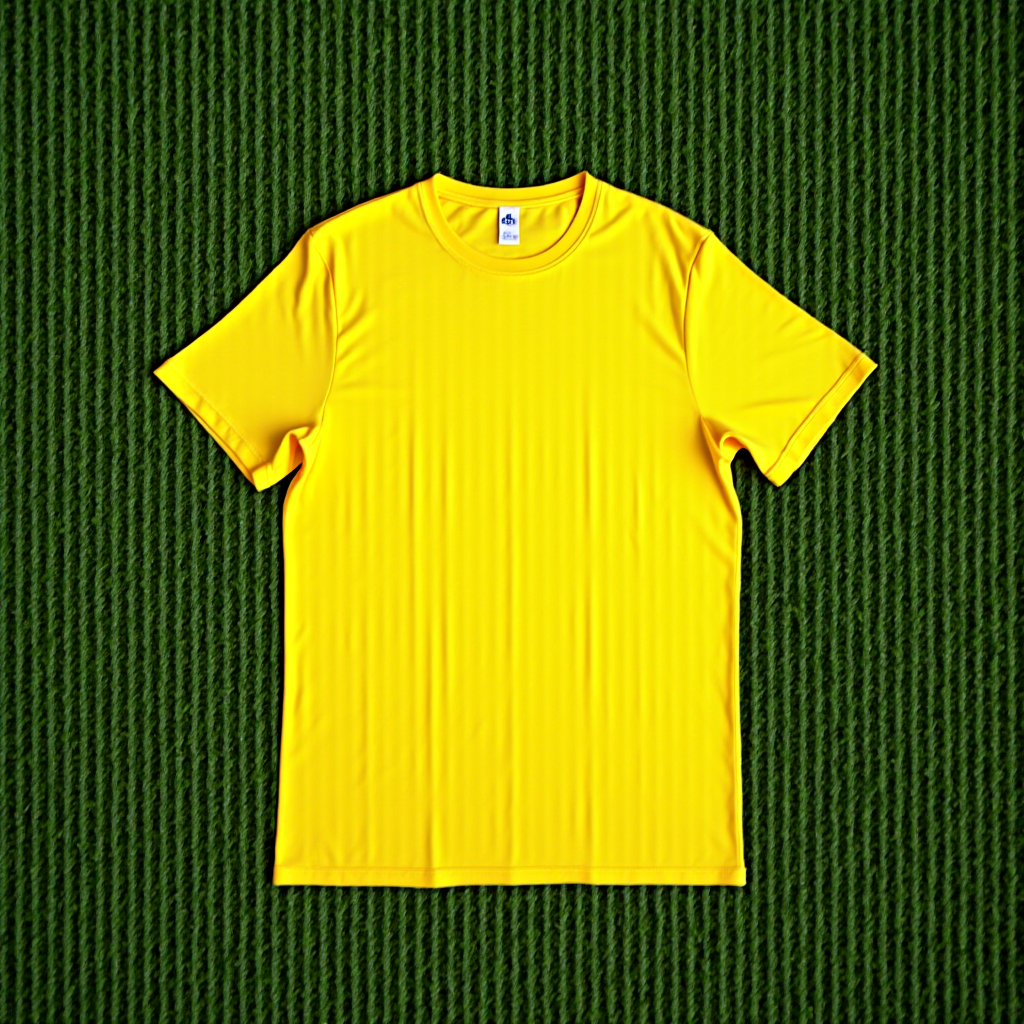

In [16]:
pipe.skipped_latents = []
pipe.unskipped_latents = []
pipe.patch_prompt = "A yellow tshirt with a print that says 'Enjoy the Sun!' laying in the grass."
image = pipe(
    "A yellow tshirt without any prints laying in the grass.",
    generator=torch.Generator("cpu").manual_seed(42),
    num_inference_steps=20
).images[0]
image

In [18]:
layer_diffs = []
for timestep in range(20): 
    timestep_prediction = pipe.unskipped_latents[timestep]
    timestep_baseline = pipe.skipped_latents[timestep][19]

    diff_baseline = (timestep_prediction - timestep_baseline)
    squared_norm_baseline = torch.sum(diff_baseline ** 2, dim=[0,1,2])

    layer_diffs_per_timestep = []
    for layer in range(19):
        diff = (timestep_prediction - pipe.skipped_latents[timestep][layer])
        squared_norm = torch.sum(diff ** 2, dim=[0,1,2]) 
        layer_diffs_per_timestep.append(squared_norm) #- squared_norm_baseline
    layer_diffs.append(torch.stack(layer_diffs_per_timestep))
layer_diffs = torch.stack(layer_diffs)

layer_weights = torch.tensor([
    0.210832,  # layer_0
    0.213569,  # layer_1
    0.202250,  # layer_2
    0.222501,  # layer_3
    0.234267,  # layer_4
    0.223289,  # layer_5
    0.217554,  # layer_6
    0.220197,  # layer_7
    0.208817,  # layer_8
    0.235654,  # layer_9
    0.219634,  # layer_10
    0.207371,  # layer_11
    0.213037,  # layer_12
    0.202450,  # layer_13
    0.223037,  # layer_14
    0.234514,  # layer_15
    0.214499,  # layer_16
    0.221948,  # layer_17
    0.216414,  # layer_18
])[:]

layer_weights =    torch.tensor([ 0.231960,  0.230319,  0.147445,  0.211755,  0.210885,  0.202199,  0.216633,  0.206342,  0.222167,  0.195722, 0.210882, 0.198651, 0.204099, 0.205225, 0.216540, 0.215737, 0.215030, 0.216897, 0.216760])


# Example tensors
tensor1 = layer_weights.to('cpu')[3:]

tensor2 = layer_diffs[:].mean(dim=0).to('cpu')[3:]
#tensor2 = cosine_sims.mean(dim=0).to('cpu')[3:]
#tensor2 = cosine_sims[i].to('cpu')[3:]

# Spearman correlation (using scipy)
spearman_corr, p_value = spearmanr(tensor1.numpy(), tensor2.numpy())
print(f"Spearman correlation: {spearman_corr:.6f}")
print(f"Spearman p-value: {p_value:.6f}")

# Alternative: Using torch.corrcoef for Pearson
stacked = torch.stack([tensor1, tensor2])
corr_matrix = torch.corrcoef(stacked)
pearson_corr_alt = corr_matrix[0, 1]
print(f"Pearson correlation (torch.corrcoef): {pearson_corr_alt.item():.6f}")

Spearman correlation: -0.308062
Spearman p-value: 0.245725
Pearson correlation (torch.corrcoef): nan


In [6]:
layer_diffs = []
for timestep in range(3): 
    timestep_prediction = pipe.unskipped_latents[timestep]
    timestep_baseline = pipe.skipped_latents[timestep][19]

    diff_baseline = (timestep_prediction - timestep_baseline)
    squared_norm_baseline = torch.sum(diff_baseline ** 2, dim=[0,1,2])

    layer_diffs_per_timestep = []
    for layer in range(19):
        diff = (timestep_prediction - pipe.skipped_latents[timestep][layer])
        squared_norm = torch.sum(diff ** 2, dim=[0,1,2]) 
        layer_diffs_per_timestep.append(squared_norm) #- squared_norm_baseline
    layer_diffs.append(torch.stack(layer_diffs_per_timestep))
layer_diffs = torch.stack(layer_diffs)

In [7]:
layer_diffs

tensor([[21344.0000, 21104.0000, 21088.0000, 21296.0000, 21104.0000, 20752.0000,
         21008.0000, 21200.0000, 21472.0000, 21472.0000, 20768.0000, 20656.0000,
         20992.0000, 20864.0000, 20448.0000, 20320.0000, 20544.0000, 20000.0000,
         18096.0000],
        [ 1593.0000,  1597.0000,  1567.0000,  1550.0000,  1569.0000,  1564.0000,
          1535.0000,  1582.0000,  1524.0000,  1518.0000,  1559.0000,  1422.0000,
          1445.0000,  1474.0000,  1579.0000,  1523.0000,  1485.0000,  1482.0000,
          1092.0000],
        [  301.2500,   301.2500,   296.5000,   300.7500,   290.2500,   297.7500,
           278.7500,   284.7500,   250.6250,   288.5000,   303.0000,   284.2500,
           298.5000,   271.7500,   302.2500,   285.0000,   269.7500,   236.2500,
           241.7500]], device='cuda:0', dtype=torch.float16)

In [9]:
layer_diff_for_prompt = []
cosine_sims_for_prompt = []
layer_diff_for_prompt_normalized = []
cosine_sims_for_prompt_normalized = []

for timestep in range(3): 
    layer_diffs_per_timestep = []
    cosine_sims_per_timestep = []
    layer_diffs_per_timestep_normalized = []
    cosine_sims_per_timestep_normalized = []

    timestep_prediction = pipe.unskipped_latents[timestep]
    timestep_baseline = pipe.skipped_latents[timestep][19]
    diff_baseline = (timestep_prediction - timestep_baseline)
    squared_norm_baseline = torch.sum(diff_baseline ** 2, dim=[0,1,2])
    sim_baseline = F.cosine_similarity(timestep_prediction.flatten(), pipe.skipped_latents[timestep][19].flatten(), dim=0)

    for layer in range(19):
        diff = (timestep_prediction - pipe.skipped_latents[timestep][layer])
        squared_norm = torch.sum((diff ** 2), dim=[0,1,2])
        cosine_sim = F.cosine_similarity(timestep_prediction.flatten(), pipe.skipped_latents[timestep][layer].flatten(), dim=0)

        layer_diffs_per_timestep.append(squared_norm.item())
        cosine_sims_per_timestep.append(cosine_sim.item())

        layer_diffs_per_timestep_normalized.append((squared_norm / squared_norm_baseline).item())
        cosine_sims_per_timestep_normalized.append((cosine_sim / sim_baseline).item())

    layer_diff_for_prompt.append(layer_diffs_per_timestep)
    cosine_sims_for_prompt.append(cosine_sims_per_timestep)

    layer_diff_for_prompt_normalized.append(layer_diffs_per_timestep_normalized)
    cosine_sims_for_prompt_normalized.append(cosine_sims_per_timestep_normalized)


In [15]:
layer_diff_for_prompt_normalized

[[1.033203125,
  1.021484375,
  1.0205078125,
  1.03125,
  1.021484375,
  1.0048828125,
  1.0166015625,
  1.0263671875,
  1.0390625,
  1.0390625,
  1.005859375,
  1.0,
  1.0166015625,
  1.009765625,
  0.98974609375,
  0.98388671875,
  0.99462890625,
  0.96826171875,
  0.8759765625],
 [1.005859375,
  1.0087890625,
  0.98974609375,
  0.97900390625,
  0.9912109375,
  0.98779296875,
  0.9697265625,
  0.99951171875,
  0.962890625,
  0.958984375,
  0.98486328125,
  0.8984375,
  0.91259765625,
  0.93115234375,
  0.99755859375,
  0.9619140625,
  0.93798828125,
  0.93603515625,
  0.68994140625],
 [1.0029296875,
  1.0029296875,
  0.98681640625,
  1.0009765625,
  0.9658203125,
  0.99072265625,
  0.927734375,
  0.94775390625,
  0.833984375,
  0.9599609375,
  1.0087890625,
  0.94580078125,
  0.9931640625,
  0.904296875,
  1.005859375,
  0.9482421875,
  0.8974609375,
  0.7861328125,
  0.8046875]]